# Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns


from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


In [6]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys

# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent.parent

# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria

# URLs y constantes

In [3]:
BASE_URL = os.path.join('/mnt/', 'c')
BASE_DATA_URL = os.path.join('/mnt/', 'e')
COMP_URL = os.path.join(BASE_URL, 'Users', 'marco', 'Desktop', 'MASTER', 'MASTER', 'DMEyF', 'COMP1')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')
DATA_URL = os.path.join(DATA_FOLDER, 'competencia_01_crudo.csv')
DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')

SEED = 230047

# UTILS

In [4]:
def van_dongen_normalized(contingency):
    n = contingency.values.sum()
    sum_max_rows = contingency.max(axis=1).sum()  # para cada label, max sobre clusters
    sum_max_cols = contingency.max(axis=0).sum()  # para cada cluster, max sobre labels
    max_row_total = contingency.sum(axis=1).max()
    max_col_total = contingency.sum(axis=0).max()
    
    vdn = (2*n - sum_max_rows - sum_max_cols) / (2*n - max_row_total - max_col_total)
    return vdn

# LEEMOS DATOS

In [5]:
df = pd.read_csv(
    DATA_TERNARIA_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

/tmp/ipykernel_2056/3175415450.py:1: DtypeWarning: Columns (0: ternaria) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


# Ppreprocesamos

## Tipos de datos 

In [6]:
df.dtypes.unique()

array([dtype('int64'), dtype('int32'), dtype('float64'),
       <StringDtype(na_value=nan)>], dtype=object)

In [7]:
for dtpye in df.dtypes.items():
    if 'int' not in str(dtpye[1]) and 'float' not in str(dtpye[1]) :
            print(dtpye[0] , ",",dtpye[1])

ternaria , str


## Sparcity

In [8]:
df['ternaria'].value_counts(dropna=False)

ternaria
continua    645999
NaN         327892
BAJA+1        5103
BAJA+2        4067
Name: count, dtype: int64

In [9]:
mask_baja = df['ternaria'].str.contains('BAJA') 

In [10]:
df.loc[mask_baja]['mcuenta_corriente_adicional'].value_counts()

mcuenta_corriente_adicional
 0.00        9162
 9.60           2
 13179.15       1
 13158.74       1
-1301.42        1
-790.30         1
-625.80         1
-867.51         1
Name: count, dtype: int64

In [11]:
proporcion_ceros = (
    df.loc[mask_baja].select_dtypes(include="number")
      .eq(0)
      .sum()
      .div(len(df.loc[mask_baja]))
      .sort_values(ascending=False)
)
threshold = .9
sparse_columns = []
for columna in proporcion_ceros.items():
    if columna[1]>threshold:
        print( columna)
        sparse_columns.append(columna[0])
print(len(sparse_columns))



('mpayroll2', 0.9996728462377318)
('cpayroll2_trx', 0.9996728462377318)
('cliente_vip', 0.999236641221374)
('ccheques_depositados_rechazados', 0.9991275899672846)
('minversion1_dolares', 0.9991275899672846)
('mcuenta_corriente_adicional', 0.9991275899672846)
('mcheques_depositados_rechazados', 0.9991275899672846)
('mplazo_fijo_pesos', 0.9986913849509269)
('mcheques_emitidos_rechazados', 0.9983642311886587)
('ccheques_emitidos_rechazados', 0.9983642311886587)
('mpagodeservicios', 0.9982551799345692)
('cpagodeservicios', 0.9982551799345692)
('cprestamos_hipotecarios', 0.9977099236641221)
('mprestamos_hipotecarios', 0.9977099236641221)
('mcheques_emitidos', 0.9944383860414395)
('ccheques_emitidos', 0.9944383860414395)
('mforex_buy', 0.9940021810250818)
('cforex_buy', 0.9940021810250818)
('mprestamos_prendarios', 0.993784078516903)
('cforex_sell', 0.9936750272628135)
('mforex_sell', 0.9936750272628135)
('ccheques_depositados', 0.9935659760087241)
('mcheques_depositados', 0.9935659760087241

# CLUSTERS

In [12]:
columnas_excluir = [
    "numero_de_cliente",
    "foto_mes",
    "ternaria"
]
def get_random_continua(k, mask_baja):
    indices_random_continua = (
        df.loc[df["ternaria"] == "continua"]
        .sample(
            n=round(mask_baja.sum() / k),
            random_state=SEED
        )
        .index)
    mask_random_continua = df.index.isin(indices_random_continua)
    return mask_random_continua


In [13]:
k = 5
# agrego registros q no son de baja, quiero ver si el clustering los distingue
mask_random = get_random_continua(k,mask_baja)
df_baja = df.loc[mask_baja|mask_random].copy()
df_baja.fillna(0, inplace=True) #naively filll with 0s
X = df_baja.drop(columns = columnas_excluir).select_dtypes(include='number')
labels_reales = df_baja['ternaria']
X_escalado = StandardScaler().fit_transform(X)

## NAIVE K-MEANS

In [14]:
kmeans = KMeans(
    n_clusters=k+1,
    n_init=20,
    random_state=SEED
)
df_baja["K-mean-5-naive"] = kmeans.fit_predict(X_escalado)

In [15]:
pd.crosstab(
    df_baja["K-mean-5-naive"],
    df_baja["ternaria"],
    margins=True
)
labels = kmeans.labels_
print("Inercia:", kmeans.inertia_)                          # menor
print("Iteraciones:", kmeans.n_iter_)
print("Silhouette:", silhouette_score(X_escalado, labels)) # mayor
print("Davies-Bouldin:", davies_bouldin_score(X_escalado, labels))  # menor
print("Calinski-Harabasz:", calinski_harabasz_score(X_escalado, labels))  # mayor

Inercia: 1451794.90906473
Iteraciones: 35
Silhouette: 0.05067899780593492
Davies-Bouldin: 2.5145400882716955
Calinski-Harabasz: 317.87977148991416


# Hirarchical

In [16]:
hier_model = AgglomerativeClustering(
    n_clusters=k,
    # linkage='average',
    linkage='ward',
    # metric='cosine'
    metric='euclidean'
)
cluster_labels = hier_model.fit_predict(X_escalado)
df_baja["hier-5-cosine-naive"] = cluster_labels

In [17]:
silhouette_score(X_escalado, cluster_labels),


(0.15524234533635511,)

In [18]:
pd.crosstab(
    df_baja["hier-5-cosine-naive"],
    df_baja["ternaria"],
    margins=True
)

ternaria,BAJA+1,BAJA+2,continua,All
hier-5-cosine-naive,,,,
0,3822,2962,474,7258
1,91,92,168,351
2,1189,1012,1189,3390
3,1,1,0,2
4,0,0,3,3
All,5103,4067,1834,11004


# PCA

In [19]:
# Aplicamos PCA
pca = PCA()
pca.fit(X)


# Calculamos varianza acumulada para seleccionar cuantas dimensiones mantememos
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
varianza_acumulada

array([0.91798074, 0.94932757, 0.96564218, 0.97825997, 0.98295499,
       0.98635448, 0.98843076, 0.99046031, 0.99243745, 0.99389409,
       0.995295  , 0.99615913, 0.99691493, 0.99738808, 0.99780425,
       0.99820123, 0.99850561, 0.99878411, 0.99897681, 0.99912884,
       0.99927297, 0.99939232, 0.99949018, 0.99957601, 0.99965603,
       0.99973293, 0.99979979, 0.99984368, 0.99988066, 0.99990435,
       0.99992133, 0.99993639, 0.99995098, 0.99996337, 0.99997234,
       0.99997802, 0.99998169, 0.9999847 , 0.99998758, 0.99998957,
       0.9999914 , 0.9999931 , 0.99999468, 0.99999593, 0.99999698,
       0.99999798, 0.99999861, 0.99999892, 0.99999921, 0.99999946,
       0.99999969, 0.99999976, 0.99999983, 0.99999989, 0.99999993,
       0.99999996, 0.99999998, 0.99999999, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

In [20]:
pca_10= pca.transform(X)[:, :10]
pca_3= pca.transform(X)[:, :3]
type(pca_10), pca_10.shape

(numpy.ndarray, (11004, 10))

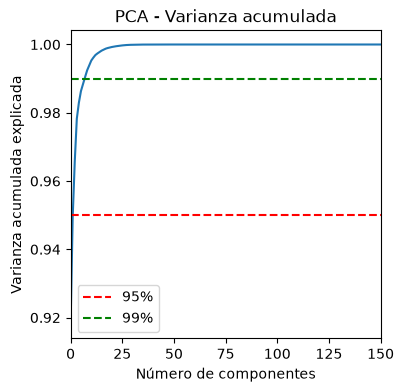

Tomamos los primeros 10 componentes, explicando 99.5% de la varianza
En los primeros 3 componentes, la varianza explicada es de 97.8% 


In [21]:
# Ploteamos
plt.figure(figsize=(4, 4))
plt.plot(varianza_acumulada)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.99, color='g', linestyle='--', label='99%')
plt.xlim(0, 150)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.legend()
plt.title('PCA - Varianza acumulada')
plt.show()

print(f'Tomamos los primeros 10 componentes, explicando {varianza_acumulada[10]*100:.3}% de la varianza')
print(f'En los primeros 3 componentes, la varianza explicada es de {varianza_acumulada[3]*100:.3}% ')

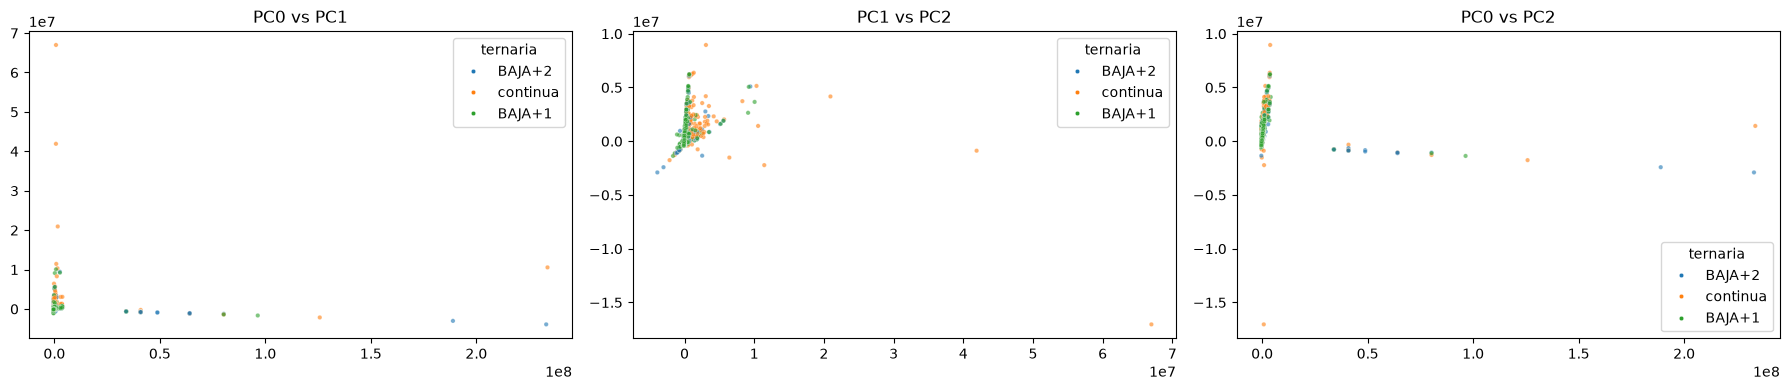

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# Definiomos la paleta para usar la misma en los 3 plots
# palette = {str(i): cm.nipy_spectral(i / 5) for i in range(5)}
# palette_with_names = {v: cm.nipy_spectral(i / 5) for i, v in enumerate(VARIEDADES)}

# Scatter plots para visualizar dimensiones cruzadas  

# Reducimos la cantidad de muestras en los scatter para q no queden demasiado saturados
sample_frac = 0.05
sample_idx = np.random.choice(len(pca_10), size=int(len(pca_10) * sample_frac), replace=False)

# pca_sample = pca_fc2_150[sample_idx]
# labels_sample = labels_fc1_fc2[sample_idx]
pca_sample = pca_10
labels_sample = labels_reales

sns.scatterplot(x=pca_sample[:,0], y=pca_sample[:,1], ax = ax1, hue=labels_sample.astype(str), s=10, alpha=0.6)
ax1.set_title('PC0 vs PC1')

# ax3.set_title('aspect_ratio vs superficie')
# ax2.legend(handles=legend_elements, title='Variedad')

# largo vs ancho
sns.scatterplot(x=pca_sample[:,1], y=pca_sample[:,2], ax = ax2, hue=labels_sample.astype(str), s=10, alpha=0.6)
ax2.set_title('PC1 vs PC2')

sns.scatterplot(x=pca_sample[:,0], y=pca_sample[:,2], ax = ax3, hue=labels_sample.astype(str), s=10, alpha=0.6)
ax3.set_title('PC0 vs PC2')

# Hacemos los puntos en los labels solidos
# 2. Grab the legend object
leg = ax3.get_legend()
# 3. Force the legend marker icons to be fully opaque
for lh in leg.legend_handles:
    lh.set_alpha(1.0)

leg = ax2.get_legend()
# 3. Force the legend marker icons to be fully opaque
for lh in leg.legend_handles:
    lh.set_alpha(1.0)

leg = ax1.get_legend()
# 3. Force the legend marker icons to be fully opaque
for lh in leg.legend_handles:
    lh.set_alpha(1.0)

plt.tight_layout()
plt.show()

## K-Means sobre PCA

In [23]:
kmeans = KMeans(
    n_clusters=k+1,
    n_init=20,
    random_state=SEED
)
df_baja["K-mean-5-pca10"] = kmeans.fit_predict(pca_10)

In [24]:
labels = kmeans.labels_
print("Inercia:", kmeans.inertia_)                          # menor
print("Iteraciones:", kmeans.n_iter_)
print("Silhouette:", silhouette_score(X_escalado, labels)) # mayor
print("Davies-Bouldin:", davies_bouldin_score(X_escalado, labels))  # menor
print("Calinski-Harabasz:", calinski_harabasz_score(X_escalado, labels))  # mayor

pd.crosstab(
    df_baja["K-mean-5-pca10"],
    df_baja["ternaria"],
    margins=True
)


Inercia: 1.685345358993774e+16
Iteraciones: 11
Silhouette: 0.25840642812261805
Davies-Bouldin: 2.328396320500855
Calinski-Harabasz: 90.66692425105614


ternaria,BAJA+1,BAJA+2,continua,All
K-mean-5-pca10,,,,
0,4784,3796,1555,10135
1,2,4,3,9
2,0,2,1,3
3,6,9,6,21
4,311,256,267,834
5,0,0,2,2
All,5103,4067,1834,11004


In [25]:
kmeans = KMeans(
    n_clusters=k+1,
    n_init=20,
    random_state=SEED
)
df_baja["K-mean-5-pca3"] = kmeans.fit_predict(pca_3)

In [26]:
labels = kmeans.labels_
print("Inercia:", kmeans.inertia_)                          # menor
print("Iteraciones:", kmeans.n_iter_)
print("Silhouette:", silhouette_score(X_escalado, labels)) # mayor
print("Davies-Bouldin:", davies_bouldin_score(X_escalado, labels))  # menor
print("Calinski-Harabasz:", calinski_harabasz_score(X_escalado, labels))  # mayor

pd.crosstab(
    df_baja["K-mean-5-pca3"],
    df_baja["ternaria"],
    margins=True
)

Inercia: 9659090352632092.0
Iteraciones: 10
Silhouette: 0.258693491780771
Davies-Bouldin: 2.348778748046672
Calinski-Harabasz: 91.2765305251542


ternaria,BAJA+1,BAJA+2,continua,All
K-mean-5-pca3,,,,
0,4778,3787,1542,10107
1,2,4,3,9
2,0,2,1,3
3,6,9,6,21
4,0,0,2,2
5,317,265,280,862
All,5103,4067,1834,11004


# Hier sobre PCA

In [27]:
hier_model = AgglomerativeClustering(
    n_clusters=k,
    # linkage='average',
    linkage='ward',
    # metric='cosine'
    metric='euclidean'
)
cluster_labels = hier_model.fit_predict(pca_10)
df_baja["hier-5-ward-eucl-pca10"] = cluster_labels

In [28]:
silhouette_score(pca_10, cluster_labels),


(0.9765838644918975,)

In [29]:
pd.crosstab(
    df_baja["hier-5-ward-eucl-pca10"],
    df_baja["ternaria"],
    margins=True
)

ternaria,BAJA+1,BAJA+2,continua,All
hier-5-ward-eucl-pca10,,,,
0,5095,4052,1823,10970
1,2,4,3,9
2,0,2,1,3
3,6,9,6,21
4,0,0,1,1
All,5103,4067,1834,11004


In [30]:
hier_model = AgglomerativeClustering(
    n_clusters=k,
    # linkage='average',
    linkage='ward',
    # metric='cosine'
    metric='euclidean'
)
cluster_labels = hier_model.fit_predict(pca_3)
df_baja["hier-5-ward-eucl-pca3"] = cluster_labels

In [31]:
silhouette_score(pca_3, cluster_labels),
pd.crosstab(
    df_baja["hier-5-ward-eucl-pca10"],
    df_baja["ternaria"],
    margins=True
)

ternaria,BAJA+1,BAJA+2,continua,All
hier-5-ward-eucl-pca10,,,,
0,5095,4052,1823,10970
1,2,4,3,9
2,0,2,1,3
3,6,9,6,21
4,0,0,1,1
All,5103,4067,1834,11004


### Another Hier

In [32]:
hier_model = AgglomerativeClustering(
    n_clusters=k,
    linkage='average',
    # linkage='ward',
    metric='cosine'
    # metric='euclidean'
)
cluster_labels = hier_model.fit_predict(pca_10)
df_baja["hier-5-avg-cos-pca10"] = cluster_labels

In [34]:
print(silhouette_score(pca_10, cluster_labels))
pd.crosstab(
    df_baja["hier-5-ward-eucl-pca10"],
    df_baja["ternaria"],
    margins=True
)


0.4979569339818348


ternaria,BAJA+1,BAJA+2,continua,All
hier-5-ward-eucl-pca10,,,,
0,5095,4052,1823,10970
1,2,4,3,9
2,0,2,1,3
3,6,9,6,21
4,0,0,1,1
All,5103,4067,1834,11004
